
PATIENT: P01 (Ch)

===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)
✅ Loaded: Data_Ch_D.csv

===== FILE: Data_Ch_G.csv =====
K-Push:
     time   force
0  0.000  0.3873

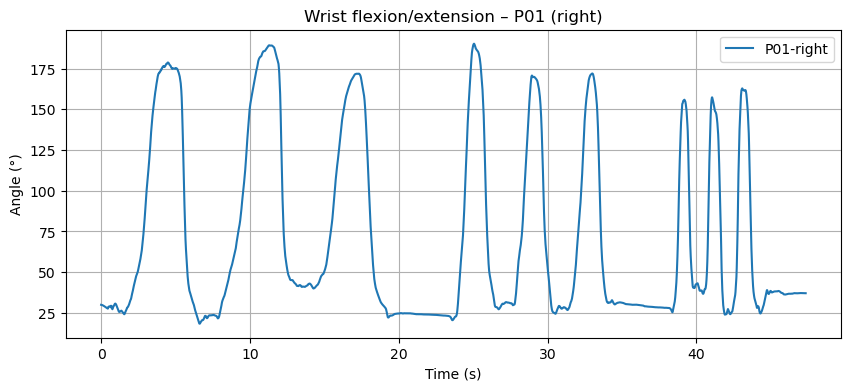

Angle range: 18.39° to 190.23°

===== P01 | LEFT =====


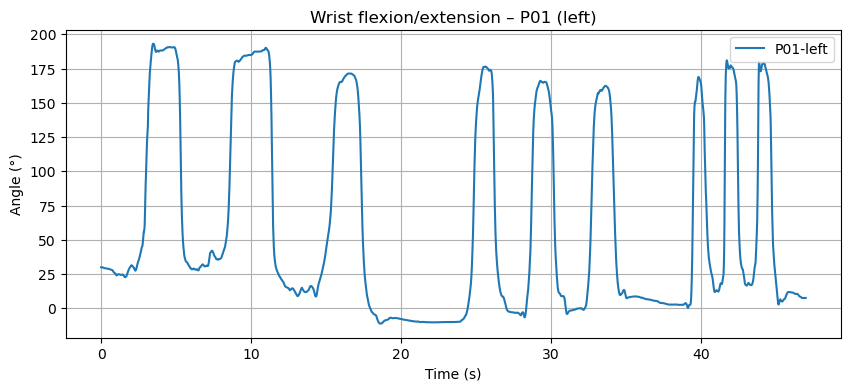

Angle range: -11.21° to 193.12°

===== P02 | RIGHT =====


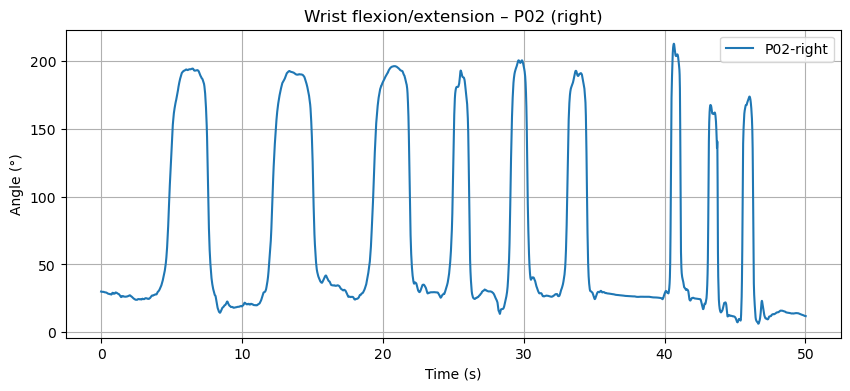

Angle range: 6.26° to 212.95°

===== P02 | LEFT =====


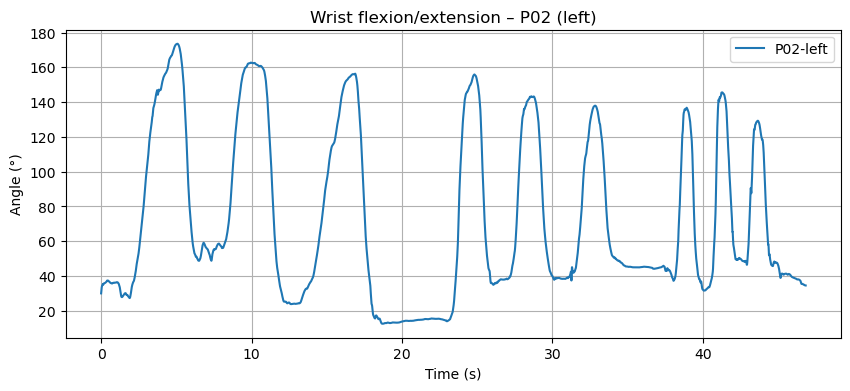

Angle range: 12.54° to 173.61°

===== P03 | RIGHT =====


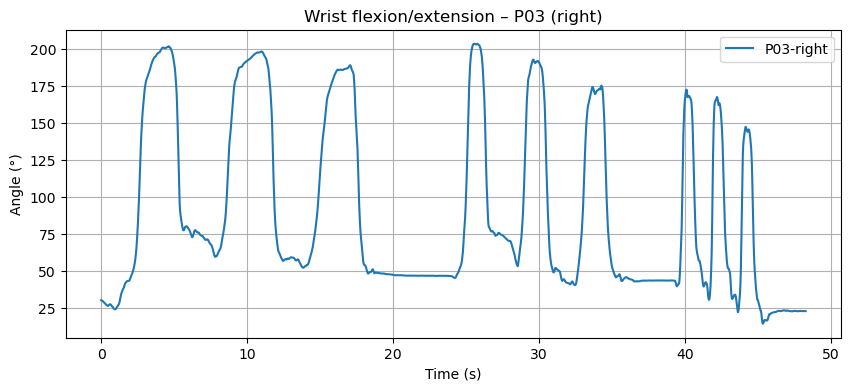

Angle range: 14.11° to 203.32°

===== P03 | LEFT =====


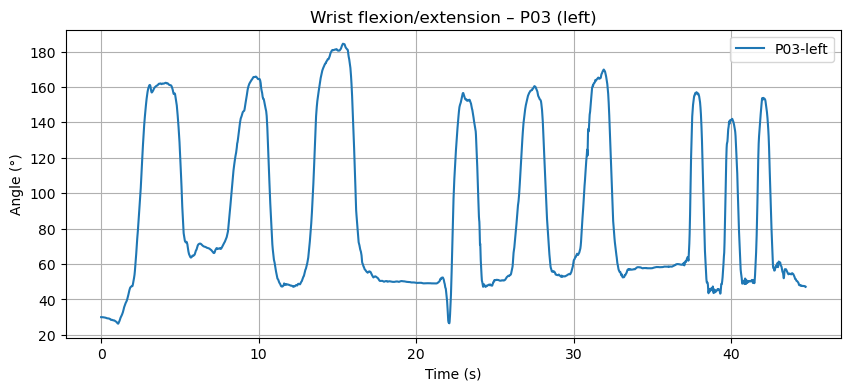

Angle range: 26.29° to 184.42°


In [1]:
# ==========================================================
# PATIENT FILES
# ==========================================================
"""
Patient data configuration for passive elbow extension study.

Author: Anais Ragon + copilot 
Date: 12/05/2026
"""
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# ---------- PATIENT CONFIGURATION ----------
# Add your patients here following this structure
PATIENTS = {
    "P01": {
        "id": "Ch",
        "right": "Data_Ch_D.csv",
        "left": "Data_Ch_G.csv"
    

    },
    "P02": {
        "id": "Lo",
        "right": "Data_Lo_D.csv",
        "left": "Data_Lo_G.csv"
  
    },
    "P03": {
        "id": "Ca",
        "right": "Data_Ca_D.csv", 
        "left": "Data_Ca_G.csv", 
    },
}

# Acquisition frequencies
FREQ_KPUSH = 1000  # Hz
FREQ_KMOVE = 250  # Hz

# ==========================================================
# LOAD FILE
# ==========================================================
def load_data(filename):

    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- K-PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            values = values[:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- DEBUG PRINT ----------
    print(f"\n===== FILE: {filename} =====")
    print("K-Push:\n", df_push.head())
    print("\nWrist:\n", df_wrist.head())
    print("\nShoulder:\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# QUATERNION UTILS
# ==========================================================
def quat_conjugate(q):
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    return q / np.linalg.norm(q)


# ==========================================================
# ANGLE CALCULATION
# ==========================================================
def quaternion_to_angle_y_calibrated(df_quat, baseline_quat, baseline_deg):

    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)

    angles = []

    for i in range(len(df_quat)):

        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])

        q = normalize_quat(q)

        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr

        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )

        angles.append(angle)

    angles = np.unwrap(np.array(angles))
    angle_deg = np.degrees(angles)

    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    angle_anatomical = angle_zeroed + baseline_deg

    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical

    return df


# ==========================================================
# Multi-patients and both sides processing + plotting
# ==========================================================

results = {}

for patient_name, patient_data in PATIENTS.items():
    print(f"\n==============================")
    print(f"PATIENT: {patient_name} ({patient_data['id']})")
    print(f"==============================")

    results[patient_name] = {}

    
    for side in ["right", "left"]:
        if side not in patient_data:
            print(f"[INFO] No {side} file for {patient_name}")
            continue

        file = patient_data[side]

        try:
            df_push, df_wrist, df_shoulder, baseline = process_file(file)

            results[patient_name][side] = {
                "file": file,
                "push": df_push,
                "wrist": df_wrist,
                "shoulder": df_shoulder,
                "baseline": baseline
            }

            print(f"✅ Loaded: {file}")

        except FileNotFoundError as e:
            print(f"[WARNING] {e}")

# ==========================================================
# Processing + plotting (multi-patients, both sides)
# ==========================================================

all_angles_data = {}

for patient_name, patient_info in results.items():
    all_angles_data[patient_name] = {}

    for side, data in patient_info.items():
        print(f"\n===== {patient_name} | {side.upper()} =====")

        baseline_quat = data["baseline"]["wrist"]
        df_wrist = data["wrist"]

        if len(baseline_quat) != 4:
            print("⚠️ Missing baseline quaternion → skipped side.")
            continue

        df_angles = quaternion_to_angle_y_calibrated(
            df_wrist, baseline_quat, baseline_deg=30
        )

        all_angles_data[patient_name][side] = df_angles

        # ---------- Plot ----------
        plt.figure(figsize=(10, 4))
        plt.plot(df_angles["time"], df_angles["angle"],
                 label=f"{patient_name}-{side}")
        plt.xlabel("Time (s)")
        plt.ylabel("Angle (°)")
        plt.title(f"Wrist flexion/extension – {patient_name} ({side})")
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"Angle range: {df_angles['angle'].min():.2f}° to {df_angles['angle'].max():.2f}°")


=== DETECTION : P01 | RIGHT ===


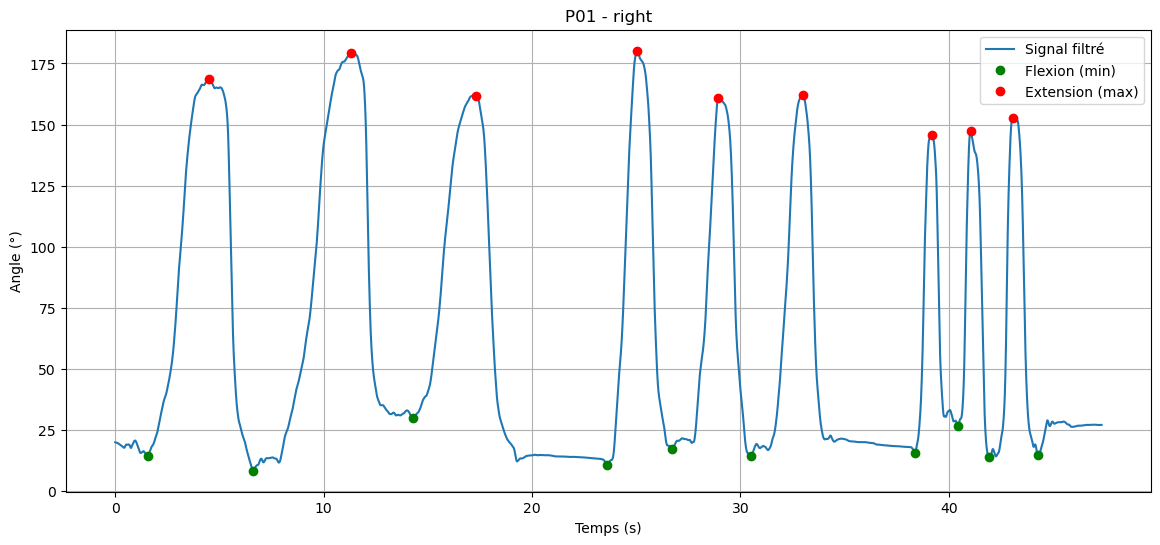


=== DETECTION : P01 | LEFT ===


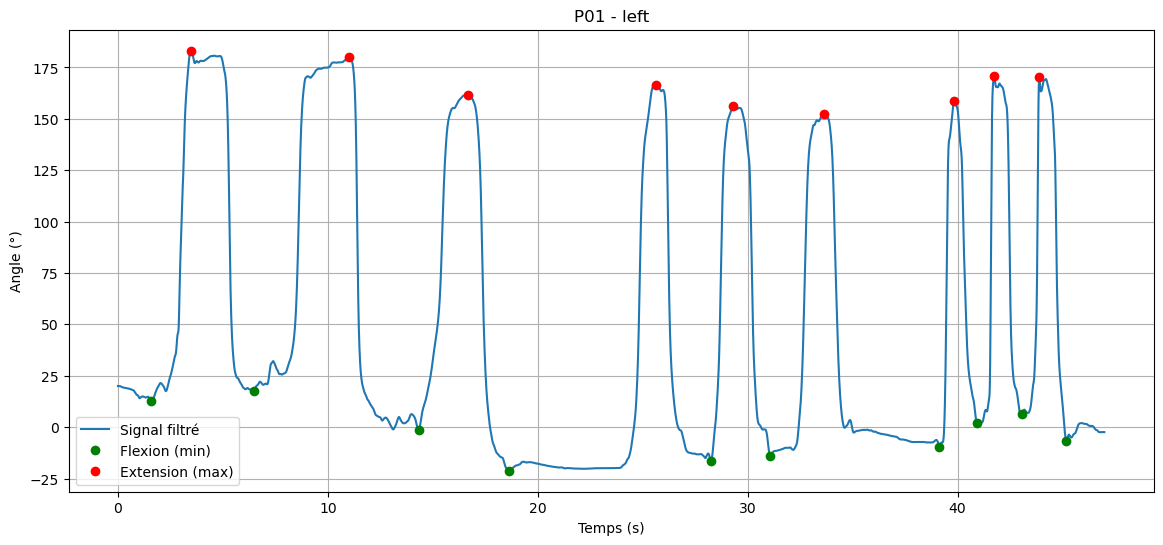


=== DETECTION : P02 | RIGHT ===


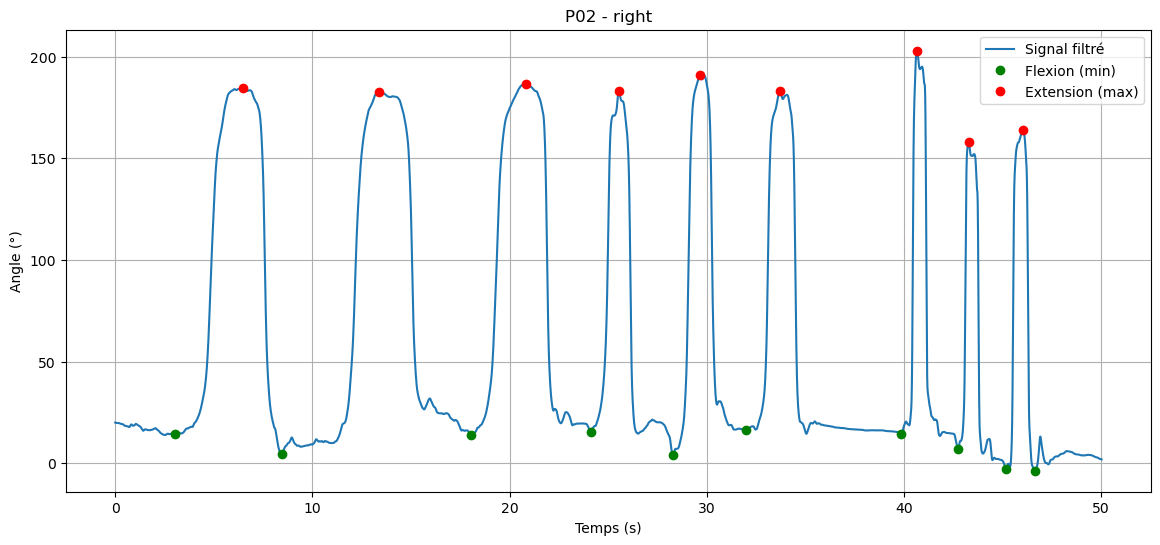


=== DETECTION : P02 | LEFT ===


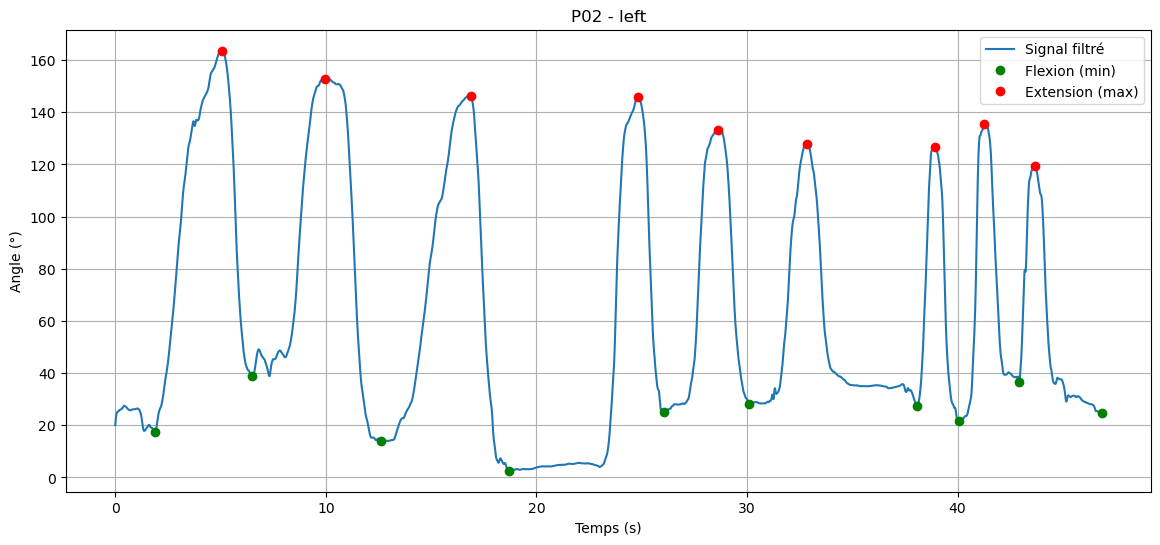


=== DETECTION : P03 | RIGHT ===


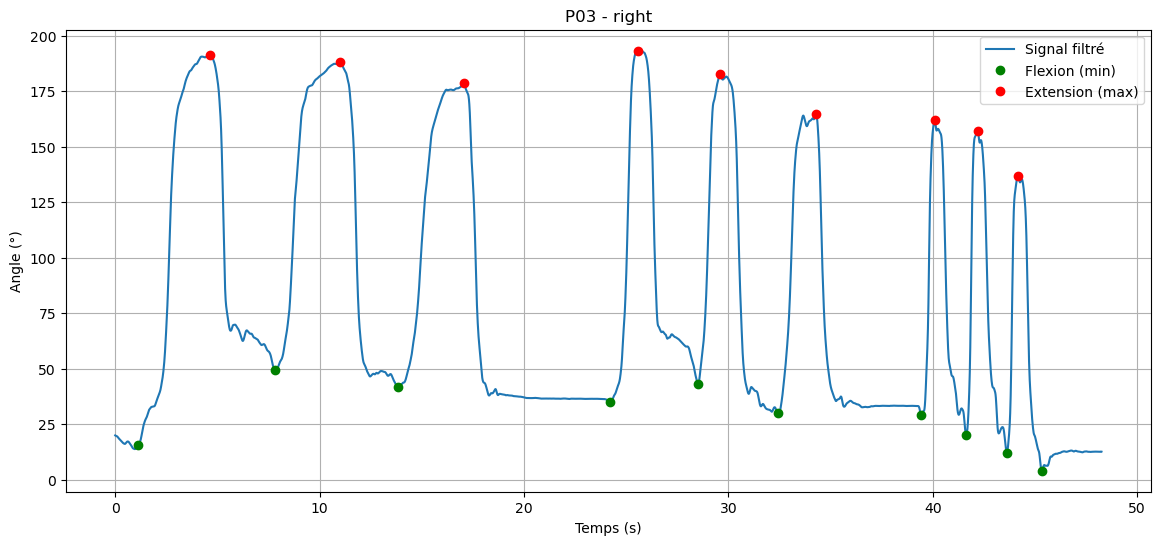


=== DETECTION : P03 | LEFT ===


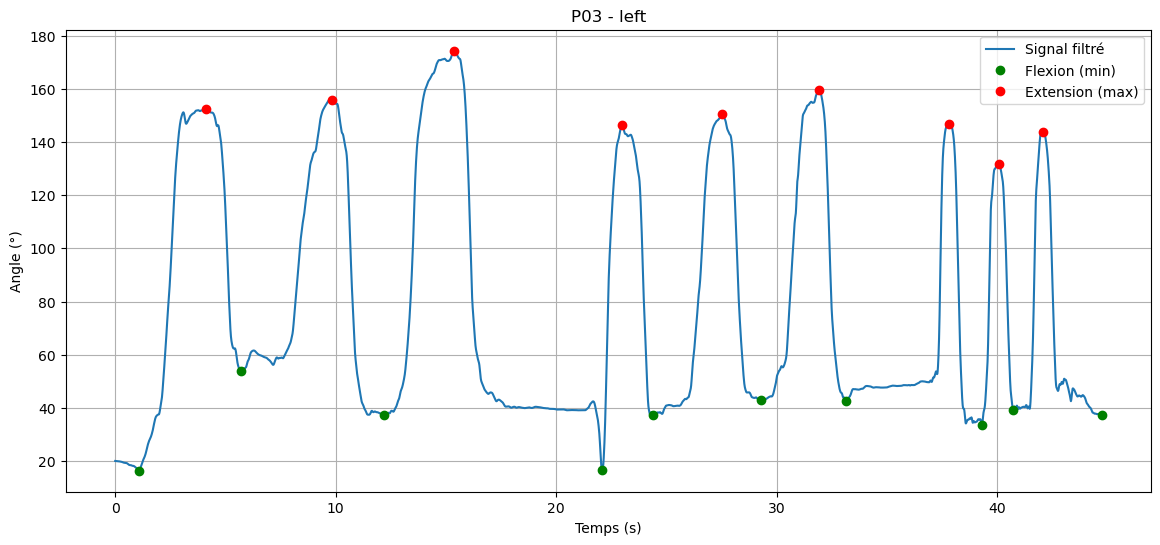


===== EVENTS: P01 | RIGHT =====

TABLE:
 event_id speed_category   velocity
        1           slow  52.614395
        2           slow  36.514885
        3           slow  43.429288
        4         medium 117.184722
        5         medium  64.361448
        6         medium  59.380786
        7           fast 161.487703
        8           fast 199.660161
        9           fast 120.097431


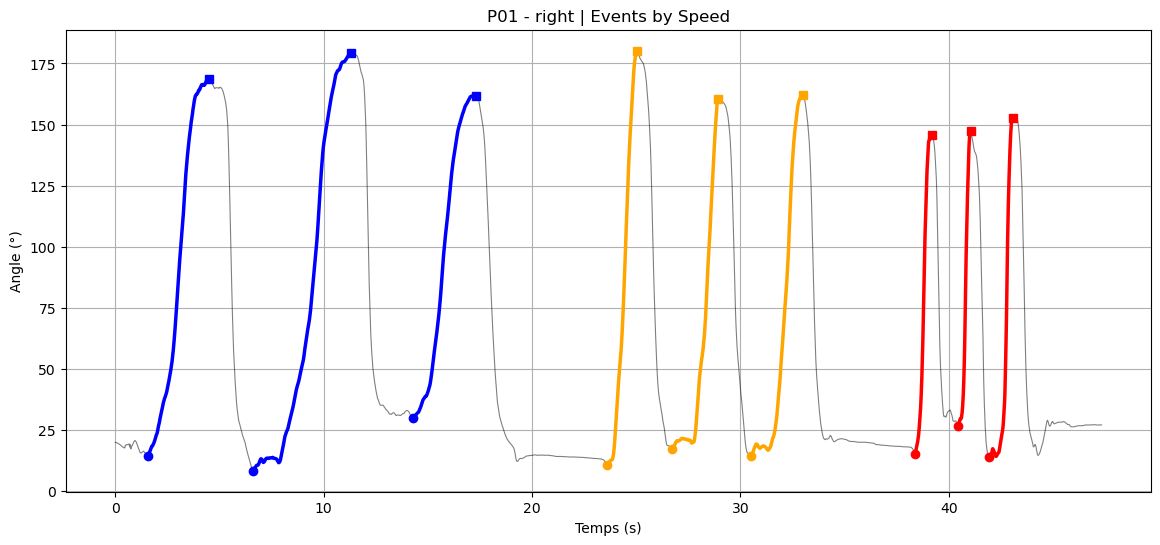


STATISTIQUES :

SLOW (n=3):
  Mean Velocity  : 44.2 °/s

MEDIUM (n=3):
  Mean Velocity  : 80.3 °/s

FAST (n=3):
  Mean Velocity  : 160.4 °/s

===== EVENTS: P01 | LEFT =====

TABLE:
 event_id speed_category   velocity
        1           slow  90.446506
        2           slow  36.023943
        3           slow  69.561258
        4         medium  26.691929
        5         medium 164.057315
        6         medium  65.344362
        7           fast 238.189577
        8           fast 210.253353
        9           fast 196.849908


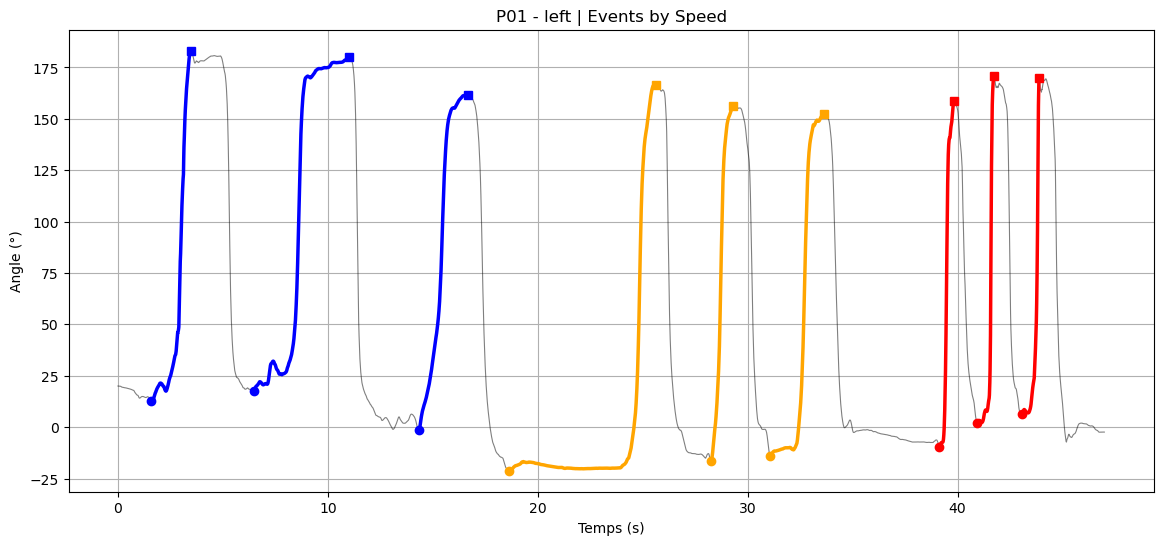


STATISTIQUES :

SLOW (n=3):
  Mean Velocity  : 65.3 °/s

MEDIUM (n=3):
  Mean Velocity  : 85.4 °/s

FAST (n=3):
  Mean Velocity  : 215.1 °/s

===== EVENTS: P02 | RIGHT =====

TABLE:
 event_id speed_category   velocity
        1           slow  49.196038
        2           slow  36.205800
        3           slow  60.915454
        4         medium 117.695237
        5         medium 140.069235
        6         medium  96.297898
        7           fast 234.558522
        8           fast 283.100652
        9           fast 194.665156


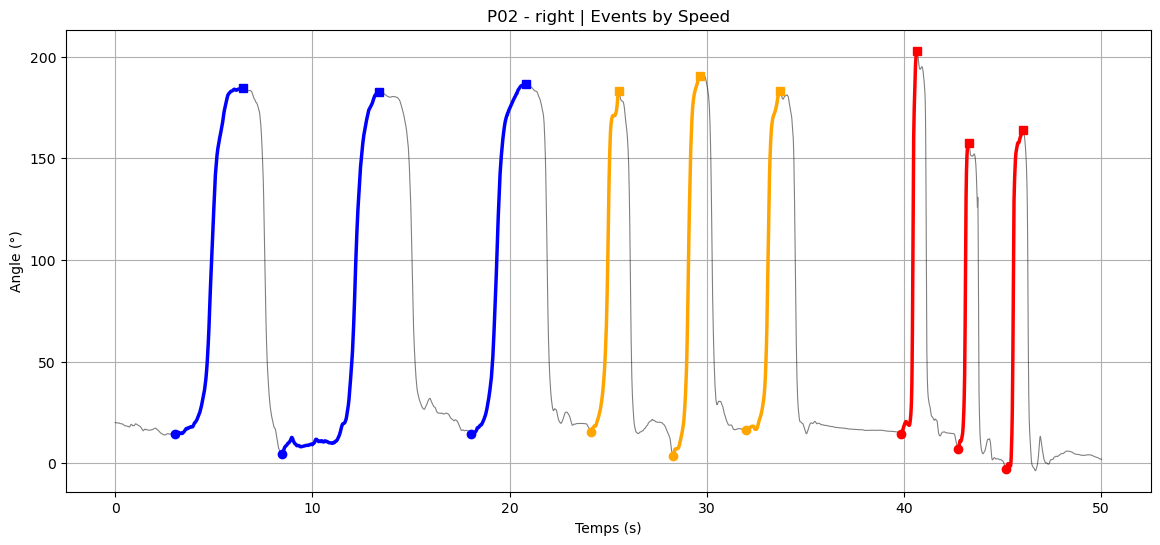


STATISTIQUES :

SLOW (n=3):
  Mean Velocity  : 48.8 °/s

MEDIUM (n=3):
  Mean Velocity  : 118.0 °/s

FAST (n=3):
  Mean Velocity  : 237.4 °/s

===== EVENTS: P02 | LEFT =====

TABLE:
 event_id speed_category   velocity
        1           slow  46.008257
        2           slow  32.949972
        3           slow  31.088123
        4         medium  23.410910
        5         medium  42.743053
        6         medium  36.629674
        7           fast 114.645531
        8           fast  95.261052
        9           fast 113.785333


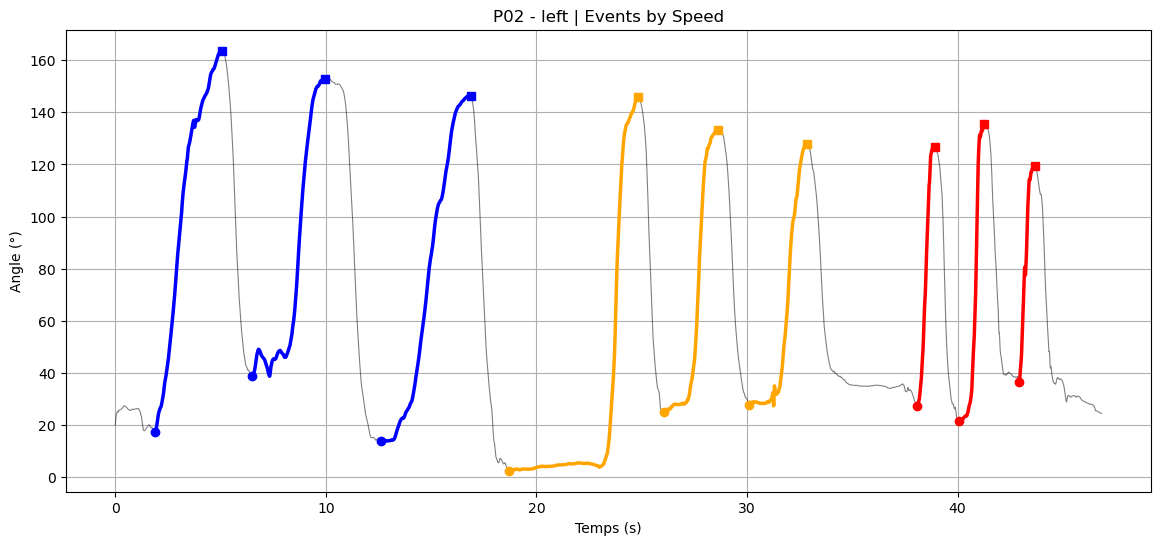


STATISTIQUES :

SLOW (n=3):
  Mean Velocity  : 36.7 °/s

MEDIUM (n=3):
  Mean Velocity  : 34.3 °/s

FAST (n=3):
  Mean Velocity  : 107.9 °/s

===== EVENTS: P03 | RIGHT =====

TABLE:
 event_id speed_category   velocity
        1           slow  50.164378
        2           slow  43.811339
        3           slow  42.710784
        4         medium 118.086832
        5         medium 131.124061
        6         medium  73.660443
        7           fast 203.421723
        8           fast 246.190196
        9           fast 238.957739


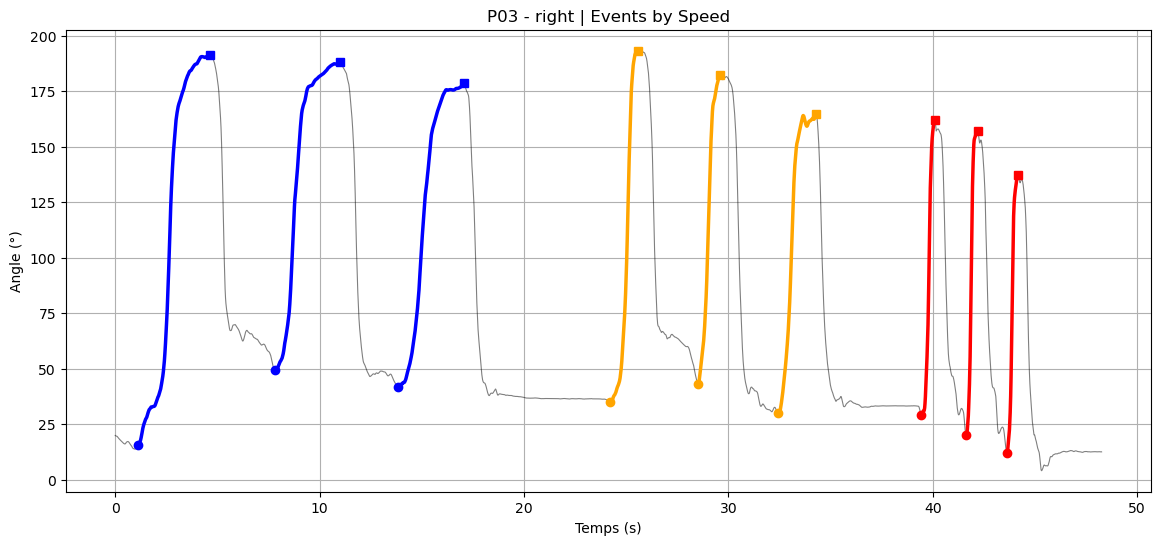


STATISTIQUES :

SLOW (n=3):
  Mean Velocity  : 45.6 °/s

MEDIUM (n=3):
  Mean Velocity  : 107.6 °/s

FAST (n=3):
  Mean Velocity  : 229.5 °/s

===== EVENTS: P03 | LEFT =====

TABLE:
 event_id speed_category   velocity
        1           slow  44.991830
        2           slow  24.854320
        3           slow  43.394741
        4         medium 145.427347
        5         medium  36.271982
        6         medium  44.764875
        7           fast  22.404048
        8           fast 129.840265
        9           fast  77.478414


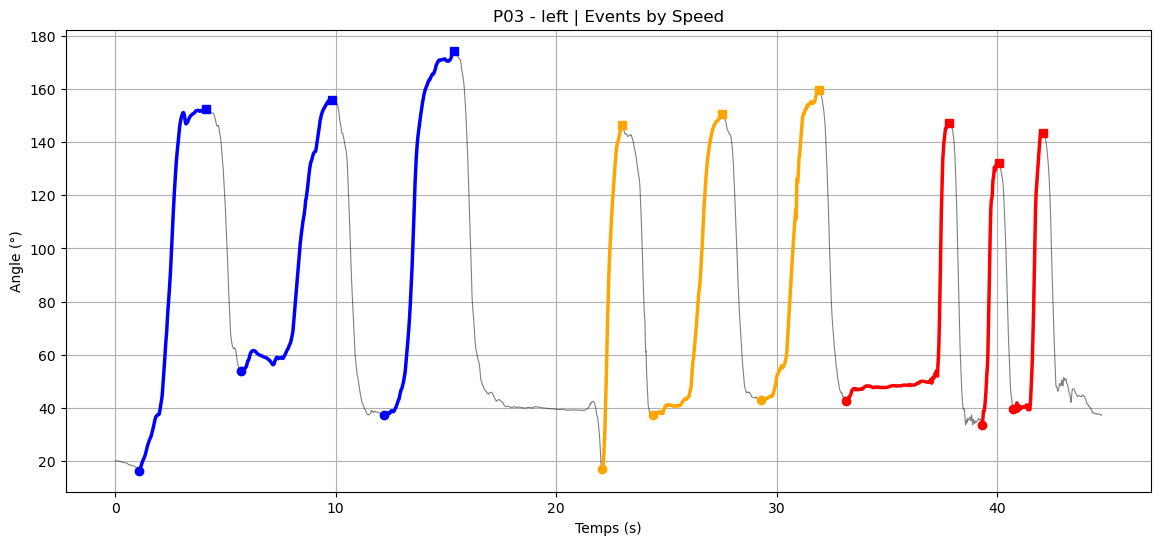


STATISTIQUES :

SLOW (n=3):
  Mean Velocity  : 37.7 °/s

MEDIUM (n=3):
  Mean Velocity  : 75.5 °/s

FAST (n=3):
  Mean Velocity  : 76.6 °/s

✅ CSV exporté : events_long_format.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMETERS
# ==========================================================
N_MAX = 9
N_MIN = 10
MIN_PROM = 15
MIN_DIST_SEC = 1.5
FILTER_CUTOFF = 10

# ==========================================================
# FILTER
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# DETECT EVENTS
# ==========================================================
def detect_clean_events(df_angles):

    time = df_angles["time"].values
    angle = df_angles["angle"].values
    fs = 1 / np.mean(np.diff(time))

    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # ---------- MAXIMA ----------
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _ = find_peaks(signal_f, distance=dist_samples, prominence=MIN_PROM)

    if len(raw_max) > N_MAX:
        idx = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]

    raw_max = np.sort(raw_max)

    # ---------- MINIMA ----------
    minima = []

    if len(raw_max) > 0:
        first_max = raw_max[0]
        start = int(max(0, first_max - 3.5 * fs))
        segment = signal_f[start:first_max]
        if len(segment) > 5:
            minima.append(start + np.argmin(segment))

    for i in range(len(raw_max) - 1):
        left = raw_max[i]
        right = raw_max[i + 1]
        segment = signal_f[left:right]
        if len(segment) > 5:
            minima.append(left + np.argmin(segment))

    if len(raw_max) > 0:
        last_max = raw_max[-1]
        segment = signal_f[last_max:]
        if len(segment) > 5:
            minima.append(last_max + np.argmin(segment))

    minima = np.array(minima, dtype=int)
    minima = np.unique(minima)

    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif len(minima) < N_MIN and len(minima) > 0:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f

# ==========================================================
# PLOT + STORE
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, patient_name, side, events_results):

    events_results.setdefault(patient_name, {})

    events_results[patient_name][side] = {
        "angles": df_angles,
        "signal_filtered": signal_f,
        "peaks_flexion": minima,
        "peaks_extension": maxima
    }

    time = df_angles["time"].values

    plt.figure(figsize=(14, 6))
    plt.plot(time, signal_f, label="Signal filtré")

    if len(minima) > 0:
        plt.plot(time[minima], signal_f[minima], "go", label="Flexion (min)")

    if len(maxima) > 0:
        plt.plot(time[maxima], signal_f[maxima], "ro", label="Extension (max)")

    plt.title(f"{patient_name} - {side}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.legend()
    plt.grid()
    plt.show()

# ==========================================================
# DETECTION MULTI-PATIENTS
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():

        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")

        df = data["wrist"]
        baseline = data["baseline"]["wrist"]

        df_angles = quaternion_to_angle_y_calibrated(df, baseline, baseline_deg=20)

        minima, maxima, signal_f = detect_clean_events(df_angles)

        plot_and_store(df_angles, minima, maxima, signal_f,
                       patient_name, side, events_results)

# ==========================================================
# EVENTS ANALYSIS
# ==========================================================
all_events_summary = {}
all_events_long = []  # <-- pour CSV final

for patient_name in events_results:

    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data = events_results[patient_name][side]

        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]

        signal = df_angles["angle"].values
        time = df_angles["time"].values

        events = []

        if len(peaks_flexion) < 2 or len(peaks_extension) == 0:
            print("⚠️ Not enough peaks")
            continue

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):

            min_idx = peaks_flexion[i]
            max_idx = peaks_extension[i]

            t_start = time[min_idx]
            t_end = time[max_idx]
            duration = t_end - t_start

            angle_start = signal[min_idx]
            angle_end = signal[max_idx]
            amplitude = angle_end - angle_start

            velocity = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id': i + 1,
                'min_idx': min_idx,
                'max_idx': max_idx,
                't_start': t_start,
                't_end': t_end,
                'duration': duration,
                'amplitude': amplitude,
                'velocity': velocity
            })

        # ---------- CLASSIFICATION ----------
        speed_labels = ['slow'] * 3 + ['medium'] * 3 + ['fast'] * 3

        for i, event in enumerate(events):
            event['speed_category'] = speed_labels[i] if i < len(speed_labels) else 'extra'

            # ajout format long (ICC ready)
            all_events_long.append({
                'subject': patient_name,
                'side': side,
                'trial': event['event_id'],
                'speed': event['speed_category'],
                'velocity': event['velocity']
            })

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events

        print("\nTABLE:")
        print(df_events[['event_id', 'speed_category', 'velocity']].to_string(index=False))

        # ---------- PLOT ----------
        colors_speed = {
            'slow': 'blue',
            'medium': 'orange',
            'fast': 'red',
            'extra': 'gray'
        }

        plt.figure(figsize=(14,6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5)

        for event in events:

            if 'min_idx' not in event or 'max_idx' not in event:
                continue

            color = colors_speed[event['speed_category']]
            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)

            plt.plot(time[idx_range], signal[idx_range], color=color, linewidth=2.5)
            plt.plot(time[event['min_idx']], signal[event['min_idx']], 'o', color=color)
            plt.plot(time[event['max_idx']], signal[event['max_idx']], 's', color=color)

        plt.title(f"{patient_name} - {side} | Events by Speed")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.show()

        # ---------- STATS ----------
        print("\nSTATISTIQUES :")

        for cat in ['slow', 'medium', 'fast']:
            subset = df_events[df_events['speed_category'] == cat]

            if len(subset) == 0:
                continue

            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Mean Velocity  : {subset['velocity'].mean():.1f} °/s")

# ==========================================================
# EXPORT CSV (ICC READY)
# ==========================================================
df_long = pd.DataFrame(all_events_long)

df_long.to_csv("events_long_format.csv", index=False)

print("\n✅ CSV exporté : events_long_format.csv")

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import butter, filtfilt, find_peaks


# ==========================================================
# STEP 2 — FULL DATA TABLE (all patients, both sides)
# ==========================================================
print("\n" + "="*60)
print("STEP 2 — FULL DATA TABLE")
print("="*60)

rows_full = []

for patient_name, sides in all_events_summary.items():
    patient_id = PATIENTS[patient_name]["id"]

    for side, df_events in sides.items():
        for _, row in df_events.iterrows():
            rows_full.append({
                "patient"       : patient_name,
                "patient_id"    : patient_id,
                "side"          : side,
                "event_id"      : int(row["event_id"]),
                "speed_category": row["speed_category"],
                "velocity"      : round(row["velocity"], 2),
            })

df_full = pd.DataFrame(rows_full)

print("\nFULL EVENT TABLE (all patients, both sides):")
print(df_full.to_string(index=False))


STEP 2 — FULL DATA TABLE

FULL EVENT TABLE (all patients, both sides):
patient patient_id  side  event_id speed_category  velocity
    P01         Ch right         1           slow     52.61
    P01         Ch right         2           slow     36.51
    P01         Ch right         3           slow     43.43
    P01         Ch right         4         medium    117.18
    P01         Ch right         5         medium     64.36
    P01         Ch right         6         medium     59.38
    P01         Ch right         7           fast    161.49
    P01         Ch right         8           fast    199.66
    P01         Ch right         9           fast    120.10
    P01         Ch  left         1           slow     90.45
    P01         Ch  left         2           slow     36.02
    P01         Ch  left         3           slow     69.56
    P01         Ch  left         4         medium     26.69
    P01         Ch  left         5         medium    164.06
    P01         Ch  left    

In [12]:
# ==========================================================
# CLEAN + STANDARDISE COLUMN NAMES (ENGLISH)
# ==========================================================

df_full = df_full.rename(columns={
    "speed_category": "speed"
})

# Harmonise names
df_full["speed"] = df_full["speed"].replace({
    "lente": "slow",
    "moyenne": "medium",
    "rapide": "fast"
})

# ==========================================================
# ADD TRIAL NUMBER PER SPEED
# ==========================================================

df_full = df_full.sort_values(by=["patient_id", "side", "speed"])

df_full["trial"] = (
    df_full
    .groupby(["patient_id", "side", "speed"])
    .cumcount() + 1
)

# Export
df_full.to_csv("velocity_trials_clean.csv", index=False)

print("✅ CSV ready for ICC")
print(df_full.head())

✅ CSV ready for ICC
   patient patient_id  side  event_id   speed  velocity  trial
51     P03         Ca  left         7    fast     22.40      1
52     P03         Ca  left         8    fast    129.84      2
53     P03         Ca  left         9    fast     77.48      3
48     P03         Ca  left         4  medium    145.43      1
49     P03         Ca  left         5  medium     36.27      2
